# Universidad del Valle de Guatemala
## CC3092 - Deep Learning

# Laboratorio 8 Mini-GPT con muestreo controlado 

**Integrantes:** 
- Dulce Ambrosio - 231143
- Angie Vela - 23764
---

## Descripcion general

El laboratorio tiene dos partes.

En la primera se entrena un Mini-GPT a nivel de carácter sobre Shakespeare y se compara cómo cambia el texto generado según la estrategia de muestreo: greedy, top-k o top-p, con distintas temperaturas.

En la segunda se usa BERT multilingüe para mostrar que sus embeddings contextuales distinguen los significados de una misma palabra ("banco", "copa", "vela"), algo que Word2Vec no logra. Se cierra con preguntas sobre GPT frente a BERT.

In [1]:
import math, time, urllib.request, os
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(1337); np.random.seed(1337)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Dispositivo:', device, '| torch', torch.__version__)

Dispositivo: cuda | torch 2.6.0+cu124


## Task 1.1 — Dataset, vocabulario y batches

In [2]:
URL = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
if not os.path.exists('input.txt'):
    urllib.request.urlretrieve(URL, 'input.txt')
text = open('input.txt', encoding='utf-8').read()
print('Caracteres totales:', len(text))

# Vocabulario a nivel de carácter + mappings bidireccionales char <-> índice
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: ''.join(itos[int(i)] for i in ids)
assert vocab_size == 65, vocab_size
print('Tamaño del vocabulario:', vocab_size)
print(repr(''.join(chars)))

# Codificar todo el texto y dividir 90/10 respetando el orden temporal (sin barajar)
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print('train:', len(train_data), '| val:', len(val_data))

# Hiperparámetros mínimos del enunciado
block_size = 128; d_model = 128; n_heads = 4; n_layers = 3
batch_size = 64; lr = 3e-4; epochs = 10
steps_per_epoch = 300   # una "época" = 300 batches aleatorios

def get_batch(split):
    """Batch de secuencias de longitud fija. y es x desplazado un paso al futuro:
    para cada posición t, el objetivo es el carácter t+1 (objetivo de language modeling)."""
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size - 1, (batch_size,))
    x = torch.stack([d[i:i + block_size] for i in ix])
    y = torch.stack([d[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch('train')
print(xb.shape, yb.shape)
print('x[0,:20]:', repr(decode(xb[0,:20])))
print('y[0,:20]:', repr(decode(yb[0,:20])))

Caracteres totales: 1115394
Tamaño del vocabulario: 65
"\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
train: 1003854 | val: 111540


torch.Size([64, 128]) torch.Size([64, 128])
x[0,:20]: ' if die, be brief,\nT'
y[0,:20]: 'if die, be brief,\nTh'


## Task 1.2 — Mini-GPT (decoder-only) y entrenamiento
Arquitectura de la Semana 6: embeddings de token + posición, bloques Transformer con **self-attention causal** (máscara triangular inferior) y MLP, y una cabeza lineal que produce los logits $z$ sobre el vocabulario.

Atención escalada: $\text{Attn}(Q,K,V)=\text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V$, con $M_{ij}=-\infty$ si $j>i$ (la máscara causal impide ver el futuro).

In [3]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, block_size):
        super().__init__()
        assert d_model % n_heads == 0
        self.h, self.dk = n_heads, d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        # Máscara causal M: triangular inferior (j <= i permitido)
        self.register_buffer('mask', torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size))
    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q, k, v = [t.view(B, T, self.h, self.dk).transpose(1, 2) for t in (q, k, v)]
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.dk)        # QK^T / sqrt(d_k)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))  # +M
        att = F.softmax(att, dim=-1)
        return self.proj((att @ v).transpose(1, 2).contiguous().view(B, T, C))

class Block(nn.Module):
    def __init__(self, d_model, n_heads, block_size):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, block_size)
        self.mlp = nn.Sequential(nn.Linear(d_model, 4 * d_model), nn.GELU(), nn.Linear(4 * d_model, d_model))
    def forward(self, x):
        x = x + self.attn(self.ln1(x))   # conexión residual + pre-LN
        return x + self.mlp(self.ln2(x))

class MiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, block_size):
        super().__init__()
        self.block_size = block_size
        self.tok = nn.Embedding(vocab_size, d_model)
        self.pos = nn.Embedding(block_size, d_model)
        self.blocks = nn.Sequential(*[Block(d_model, n_heads, block_size) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)
    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.tok(idx) + self.pos(torch.arange(T, device=idx.device))
        logits = self.head(self.ln_f(self.blocks(x)))   # z: logits crudos
        loss = None
        if targets is not None:
            # Cross-entropy: L_t = -log softmax(z_t)[y_t]  (promedio sobre todos los tokens)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

model = MiniGPT(vocab_size, d_model, n_heads, n_layers, block_size).to(device)
print('Parámetros:', sum(p.numel() for p in model.parameters()))
opt = torch.optim.AdamW(model.parameters(), lr=lr)

@torch.no_grad()
def eval_loss_full(split_data):
    """Suma de L_t y N tokens sobre TODO el split (ventanas consecutivas sin traslape)."""
    model.eval()
    total, count = 0.0, 0
    starts = list(range(0, len(split_data) - block_size - 1, block_size))
    for i in range(0, len(starts), 256):
        s = starts[i:i + 256]
        x = torch.stack([split_data[j:j + block_size] for j in s]).to(device)
        y = torch.stack([split_data[j + 1:j + block_size + 1] for j in s]).to(device)
        logits, _ = model(x)
        total += F.cross_entropy(logits.view(-1, vocab_size), y.view(-1), reduction='sum').item()
        count += y.numel()
    model.train()
    return total, count

Parámetros: 628161


In [4]:
train_hist, val_hist = [], []
t0 = time.time()
for ep in range(1, epochs + 1):
    run = 0.0
    for _ in range(steps_per_epoch):
        xb, yb = get_batch('train')
        _, loss = model(xb, yb)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        run += loss.item()
    tr = run / steps_per_epoch
    s, c = eval_loss_full(val_data); va = s / c
    train_hist.append(tr); val_hist.append(va)
    print(f'Época {ep:2d}/{epochs} | train loss {tr:.4f} | val loss {va:.4f} | {time.time()-t0:.0f}s')

Época  1/10 | train loss 2.7116 | val loss 2.4707 | 12s


Época  2/10 | train loss 2.3673 | val loss 2.2848 | 24s


Época  3/10 | train loss 2.1775 | val loss 2.1394 | 36s


Época  4/10 | train loss 2.0255 | val loss 2.0309 | 48s


Época  5/10 | train loss 1.8988 | val loss 1.9523 | 61s


Época  6/10 | train loss 1.7974 | val loss 1.8910 | 73s


Época  7/10 | train loss 1.7160 | val loss 1.8412 | 85s


Época  8/10 | train loss 1.6606 | val loss 1.8030 | 97s


Época  9/10 | train loss 1.6143 | val loss 1.7691 | 115s


Época 10/10 | train loss 1.5767 | val loss 1.7423 | 171s


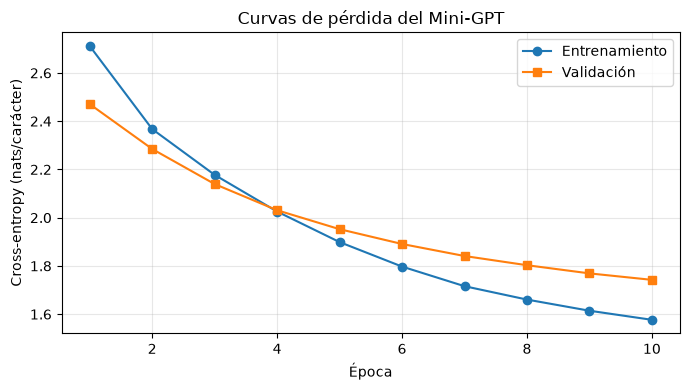

N tokens de validación = 111488 | pérdida media = 1.7423 | PERPLEJIDAD de validación = 5.711
¿Dentro del rango esperado [3.5, 8.0]? True


In [5]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), train_hist, 'o-', label='Entrenamiento')
plt.plot(range(1, epochs + 1), val_hist, 's-', label='Validación')
plt.xlabel('Época'); plt.ylabel('Cross-entropy (nats/carácter)'); plt.title('Curvas de pérdida del Mini-GPT')
plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.savefig('loss_curves.png', dpi=130); plt.show()

# Perplejidad de validación: PPL = exp( (1/N) * sum_t L_t ), N = tokens evaluados
s, c = eval_loss_full(val_data)
ppl = math.exp(s / c)
print(f'N tokens de validación = {c} | pérdida media = {s/c:.4f} | PERPLEJIDAD de validación = {ppl:.3f}')
print('¿Dentro del rango esperado [3.5, 8.0]?', 3.5 <= ppl <= 8.0)

## Task 1.3 — Funciones de muestreo desde cero
Las tres reciben **logits crudos** $z$ (vector de tamaño `vocab_size`) y devuelven el índice del siguiente token.

- **Greedy:** $w^*=\arg\max_i z_i$ (determinista).
- **Top-k con temperatura:** $z'=z/\tau$; se conservan los $k$ mayores (el resto $=-\infty$); $P(w_i)=\frac{\exp(z'_i)}{\sum_j\exp(z'_j)}$; se muestrea.
- **Top-p (nucleus) con temperatura:** $P=\text{softmax}(z/\tau)$; se ordena de mayor a menor; se incluyen tokens hasta que la prob. acumulada **supere** $p$; se renormaliza y se muestrea.

In [6]:
def sample_greedy(logits):
    # argmax_i z_i : sin aleatoriedad
    return int(torch.argmax(logits).item())

def sample_top_k(logits, k, tau):
    z = logits / tau                                  # z_i / tau
    k = min(k, z.numel())
    kth = torch.topk(z, k).values[-1]                 # k-ésimo mayor valor
    z = torch.where(z < kth, torch.full_like(z, float('-inf')), z)   # -inf a los demás
    probs = F.softmax(z, dim=-1)                      # exp(z_i)/sum_j exp(z_j) sobre los k que quedan
    return int(torch.multinomial(probs, 1).item())

def sample_top_p(logits, p, tau):
    probs = F.softmax(logits / tau, dim=-1)           # softmax con temperatura
    sp, si = torch.sort(probs, descending=True)       # ordenar de mayor a menor
    cum = torch.cumsum(sp, dim=-1)
    # Incluir tokens hasta que la prob. acumulada SUPERE p: se conserva el token si la acumulada
    # *antes* de él aún es <= p (así el token que cruza el umbral también entra).
    keep = (cum - sp) <= p
    sp = sp * keep
    sp = sp / sp.sum()                                # renormalizar
    return int(si[torch.multinomial(sp, 1).item()].item())

# Pruebas rápidas con logits sintéticos
z = torch.tensor([2.0, 1.0, 0.5, 0.1, -1.0])
print('P(softmax) =', F.softmax(z, -1).numpy().round(3))
print('greedy:', sample_greedy(z))
print('top-k(k=2) tokens muestreados:', sorted({sample_top_k(z, 2, 1.0) for _ in range(300)}), '(esperado [0, 1])')
print('top-p(p=0.5) tokens muestreados:', sorted({sample_top_p(z, 0.5, 1.0) for _ in range(300)}), '(esperado [0]: el 1er token ya acumula ~0.55 > 0.5)')
print('top-p(p=0.99) tokens muestreados:', sorted({sample_top_p(z, 0.99, 1.0) for _ in range(500)}))

P(softmax) = [0.559 0.205 0.125 0.084 0.028]
greedy: 0
top-k(k=2) tokens muestreados: [0, 1] (esperado [0, 1])
top-p(p=0.5) tokens muestreados: [0] (esperado [0]: el 1er token ya acumula ~0.55 > 0.5)
top-p(p=0.99) tokens muestreados: [0, 1, 2, 3, 4]


## Task 2.1 — Generación carácter a carácter
`generate(prompt, max_new_tokens, strategy, **kwargs)`: en cada paso se recorta el contexto a los últimos `block_size` caracteres, se obtienen los logits de la **última posición**, se elige el siguiente carácter con la estrategia y se concatena (generación autoregresiva: $P(x_{t+1}\mid x_{\le t})$).

In [7]:
@torch.no_grad()
def generate(prompt, max_new_tokens, strategy='greedy', **kwargs):
    model.eval()
    ids = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        ctx = ids[:, -block_size:]
        logits, _ = model(ctx)
        z = logits[0, -1]                              # logits del siguiente carácter
        if strategy == 'greedy':   nxt = sample_greedy(z)
        elif strategy == 'top_k':  nxt = sample_top_k(z, kwargs['k'], kwargs['tau'])
        elif strategy == 'top_p':  nxt = sample_top_p(z, kwargs['p'], kwargs['tau'])
        else: raise ValueError(strategy)
        ids = torch.cat([ids, torch.tensor([[nxt]], device=device)], dim=1)
    return decode(ids[0].tolist())

configs = {
    'A': ('greedy', {}),
    'B': ('top_k', dict(k=5,  tau=0.7)),
    'C': ('top_k', dict(k=50, tau=1.0)),
    'D': ('top_p', dict(p=0.70, tau=0.7)),
    'E': ('top_p', dict(p=0.95, tau=1.0)),
}
torch.manual_seed(2026)
samples = {}
for name, (strat, kw) in configs.items():
    samples[name] = [generate('ROMEO:', 200, strat, **kw) for _ in range(5)]
    print('=' * 70); print(f'Configuración {name}: {strat} {kw}'); print('=' * 70)
    for i, s in enumerate(samples[name], 1):
        print(f'--- muestra {name}{i} ---'); print(s)

Configuración A: greedy {}
--- muestra A1 ---
ROMEO:
What he see the strange the strange the struck of the stands
And the prove the stand to the seems of thee thee
That the such the such to the such to the such to thee
The such the such to the such to 
--- muestra A2 ---
ROMEO:
What he see the strange the strange the struck of the stands
And the prove the stand to the seems of thee thee
That the such the such to the such to the such to thee
The such the such to the such to 
--- muestra A3 ---
ROMEO:
What he see the strange the strange the struck of the stands
And the prove the stand to the seems of thee thee
That the such the such to the such to the such to thee
The such the such to the such to 
--- muestra A4 ---
ROMEO:
What he see the strange the strange the struck of the stands
And the prove the stand to the seems of thee thee
That the such the such to the such to the such to thee
The such the such to the such to 
--- muestra A5 ---
ROMEO:
What he see the strange the strange the str

Configuración B: top_k {'k': 5, 'tau': 0.7}
--- muestra B1 ---
ROMEO:
This then my for married to the poor him the dished,
Where see the partient of the profeed
Than thou strange their so them, we the strucher'd the some.

GLOUCESTER:
The man! then you, whath shore tre
--- muestra B2 ---
ROMEO:
The castrand this been man of them the proud
With have the poich the betwing have themean,
There this be thereformed at and the father to mine
And heart it one have arms, and to mights the heart
Ange
--- muestra B3 ---
ROMEO:
If the see to me be to thee, and set he stand.

LEONTES:
I'll not have thee bears and hear the fearth,
But the strung the platies the would to tell.

SLONTER:
He seaven the could the such the sould t
--- muestra B4 ---
ROMEO:
Sir, wife, and will I am the passt that
Who have haste to thee his death, they lord.

POLINES:
I will the was thee serve thee the conding of
As thee to the shier to the common the with
As him all be 
--- muestra B5 ---
ROMEO:
The warrant thou hate the 

Configuración C: top_k {'k': 50, 'tau': 1.0}
--- muestra C1 ---
ROMEO:
I came be theirse natuse and the son
By use serve and not is die, whom a-has dom amb
From York beack
And the aianoty them be forthen acher caper that:
Why doubties you const for mey tooper.

SICINIUS
--- muestra C2 ---
ROMEO:
And be gone from my hard a perset time near, Allay,
And I must him the of quice cause use of yours.

GLEONTES:
Is Isay must will I come and with numer child.

JULIET:

CAPULY CAPULA:
Besire father? s
--- muestra C3 ---
ROMEO:
Heavf their with night, some parps, by of the world
domset the isto't! Thought stop; for your oth his liament.
As poort that he urself.

GRUTER:
EL, No, it will but this love a son this pretune
Dost 
--- muestra C4 ---
ROMEO:
As purge healts both the pincaly my honours;
An a shall ratcherd's feir an eagy belt thath.

KING RICHARD III:
Now him of dannesss, are somes harmian;
Preach is from furcior counts,
But wiform all si
--- muestra C5 ---
ROMEO:
Here kinging he, do with 

Configuración D: top_p {'p': 0.7, 'tau': 0.7}
--- muestra D1 ---
ROMEO:
Have we world the power of me honour son.

PARIANA:
What we mean my say and his presenter.

COMINIUS:
I am the bear is the heart.

LUCENTIO:
I madam, the say may have seemper'd the warms,
That it sai
--- muestra D2 ---
ROMEO:
He hearth a son make the means of the compose.

Second Marrice to heard:
When thee our hast thee shore in his string
But all the wash your stand man a the was a to his die.

First Service:
I speak th
--- muestra D3 ---
ROMEO:
Herefore so the heart to so stand as hear thee,
The prophess and me and to death hate the with train.

MENENIUS:
And not his not his counted his seent thee been to thee,
The should as the bart thee t
--- muestra D4 ---
ROMEO:
Ay, then have been them the was an of the country,
And may the man heave heaven of the to strain and
And their dear her hear of the world him him.

DUKE VINCENTIO:
And besen thee so have his bear to 
--- muestra D5 ---
ROMEO:
Sir, I have mean you hav

Configuración E: top_p {'p': 0.95, 'tau': 1.0}
--- muestra E1 ---
ROMEO:
Masting is thee too dead.

CAMILLO:
For that ontain, burn so which thee night.

DUKE OF ELY:
Traninge lords but me not this fall'd and now,
Like your ware for with he overn
Rarmeolines, innoting fath
--- muestra E2 ---
ROMEO:
Shall thee, my here's shore life his from fair
this unhern the his gave assalled:
To mast creattlen of death,
The batten at what I pray more he plick,
And see hore shall meet night his hold.
And can 
--- muestra E3 ---
ROMEO:
Here pace, it blut life allood, and of I.

BUCKINGHAM:
To sidness thost lack.

QUEEN:
Ge't?

BRARDINCENBALANG:
A his I, no the good the demen to to countrains
And there recate as thee it old aborsed 
--- muestra E4 ---
ROMEO:
Ge, you rath?

GLOUCESTER:
Give oward, our sights let's wear.

KING RICHARD III:
You now you know could of the offirs;
By ariary youth sweal, no head it lefest,
And news will. Henry.

HENRY BROKENVOL
--- muestra E5 ---
ROMEO:
How go pasting lord ple

A: 4-gramas únicos = 0.39 | muestras distintas de 5 = 1
B: 4-gramas únicos = 0.83 | muestras distintas de 5 = 5
C: 4-gramas únicos = 0.96 | muestras distintas de 5 = 5
D: 4-gramas únicos = 0.85 | muestras distintas de 5 = 5
E: 4-gramas únicos = 0.96 | muestras distintas de 5 = 5

Muestra E1: probabilidad máxima del siguiente carácter, posición por posición (carácter actual -> p_max)
MÁS SEGUROS : [(89, "'K'", "'E'", 0.999), (41, "':'", "'\\n'", 0.998), (5, "':'", "'\\n'", 0.997), (98, "':'", "'\\n'", 0.997), (111, "'r'", "'d'", 0.991), (36, "'M'", "'I'", 0.976), (82, "'h'", "'t'", 0.975), (84, "'.'", "'\\n'", 0.972), (93, "'F'", "' '", 0.971), (71, "'c'", "'h'", 0.966), (39, "'L'", "'O'", 0.959), (92, "'O'", "'F'", 0.95)]
MÁS INSEGUROS: [(46, "' '", "'t'", 0.097), (86, "'\\n'", "'D'", 0.098), (33, "'\\n'", "'C'", 0.099), (6, "'\\n'", "'M'", 0.107), (22, "' '", "'t'", 0.111), (59, "' '", "'b'", 0.113), (99, "'\\n'", "'T'", 0.122), (0, "'R'", "'O'", 0.127), (51, "' '", "'o'", 0.128), (42

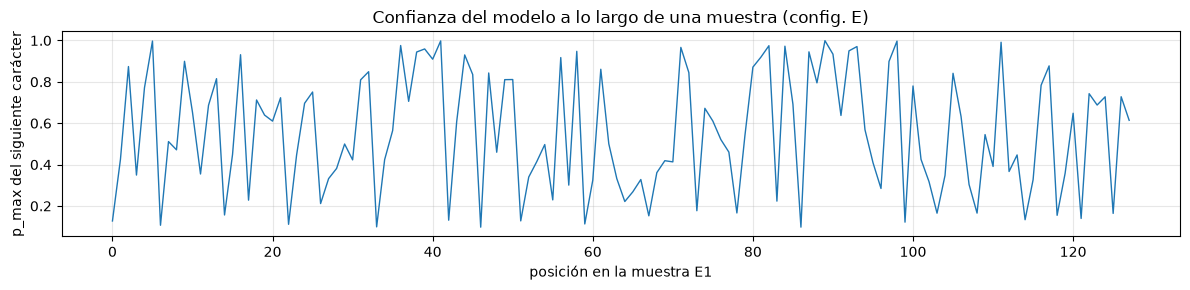

In [8]:
# Métricas de apoyo para el análisis (Task 2.2)
def uniq_ngrams(s, n=4):
    g = [s[i:i+n] for i in range(len(s)-n+1)]
    return len(set(g)) / len(g)
for name in configs:
    u = np.mean([uniq_ngrams(s[len('ROMEO:'):]) for s in samples[name]])
    d = len({s for s in samples[name]})
    print(f'{name}: 4-gramas únicos = {u:.2f} | muestras distintas de 5 = {d}')

# Confianza del modelo (prob. máxima del siguiente carácter) a lo largo de una muestra de la config. E
@torch.no_grad()
def confidence(text):
    model.eval()
    ids = torch.tensor([encode(text)], device=device)[:, -block_size:]
    logits, _ = model(ids)
    p = F.softmax(logits[0], -1)
    ent = -(p * torch.log(p + 1e-12)).sum(-1)
    return p.max(-1).values.cpu().numpy(), ent.cpu().numpy()

txt = samples['E'][0][:block_size]   # primeros 128 caracteres (cabe en el contexto)
pmax, ent = confidence(txt)
print('\nMuestra E1: probabilidad máxima del siguiente carácter, posición por posición (carácter actual -> p_max)')
rows = [(i, txt[i], txt[i+1] if i+1 < len(txt) else '', pmax[i], ent[i]) for i in range(len(txt))]
print('MÁS SEGUROS :', [(i, repr(c), repr(nx), round(float(p), 3)) for i, c, nx, p, e in sorted(rows, key=lambda r: -r[3])[:12]])
print('MÁS INSEGUROS:', [(i, repr(c), repr(nx), round(float(p), 3)) for i, c, nx, p, e in sorted(rows, key=lambda r: r[3])[:12]])

plt.figure(figsize=(12, 3))
plt.plot(pmax, lw=1); plt.xlabel('posición en la muestra E1'); plt.ylabel('p_max del siguiente carácter')
plt.title('Confianza del modelo a lo largo de una muestra (config. E)'); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig('confidence_E1.png', dpi=130); plt.show()

## Task 2.2 — Análisis (basado en las muestras generadas arriba)

**Resumen cuantitativo de este entrenamiento:** perplejidad de validación = **5.71** (dentro de [3.5, 8.0]). Fracción de 4-gramas únicos por configuración: A = 0.39, B = 0.83, C = 0.96, D = 0.85, E = 0.96. Las 5 muestras de A son **idénticas**; en B–E las 5 muestras son distintas.

### a) Greedy (A): repetición y ciclos
Greedy elige $w_{t+1}=rg\max_i P(w_i\mid x_{\le t})$, una función **determinista** del contexto. Las muestras A1–A5 son literalmente la misma cadena, y se ve el ciclo: *"That the such the such to the such to the such to thee / The such the such to the such to…"*, además de *"the strange the strange the struck"*.

Razón matemática: el modelo aprendió una distribución del siguiente carácter con entropía considerable (la mayoría de posiciones tienen una masa dominante en pocos caracteres, pero no 1.0). Greedy descarta toda la masa restante y siempre sigue la moda. Como el contexto se desplaza solo un carácter por paso y la moda de un contexto "…the such to the such to" es de nuevo "the such to…", el sistema es un mapa determinista sobre una ventana finita de 128 caracteres: en cuanto un estado (ventana) reaparece, la trayectoria se repite para siempre (ciclo límite). Además hay *retroalimentación*: cada repetición hace más probable repetir en el siguiente paso, porque el contexto repetido es una evidencia de que esa frase "va a continuar". Sin aleatoriedad no existe forma de escapar del ciclo. La distribución aprendida tiene su masa en las secuencias frecuentes del corpus ("the", "to", "thee"), así que el argmax favorece las palabras más comunes y genera la repetición de palabras funcionales.

### b) Top-k: comparación B (k=5, τ=0.7) vs C (k=50, τ=1.0)
Con $P(w_i\mid ctx)=
rac{\exp(z_i/	au)}{\sum_j\exp(z_j/	au)}$:
- **Aumentar k de 5 a 50** deja de truncar la cola: con k=50 casi todo el vocabulario (65 caracteres) puede salir, incluidos caracteres de probabilidad muy baja. Efecto sobre diversidad: 4-gramas únicos pasan de 0.83 (B) a 0.96 (C), y C introduce más ortografías inventadas y nombres de personajes variados (*"SICINIUS", "GLEONTES", "CAPULY CAPULA", "GRUTER"*) y palabras rotas (*"aianoty", "furcior", "pincaly"*).
- **Subir τ de 0.7 a 1.0** divide los logits por un número menor que 1 en B (τ=0.7 *los amplifica* por 1/0.7 ≈ 1.43), por lo que las diferencias entre logits se agrandan y la softmax queda **más concentrada** (picuda) en los caracteres más probables. Con τ=1.0 se usan los logits originales: la distribución es más plana, o sea más entropía y más probabilidad de escoger caracteres secundarios.
- **Más coherente: B.** Sus muestras mantienen palabras reales y estructura de diálogo (*"I will the was thee serve thee…", "If the see to me be to thee, and set he stand."*, nombres plausibles como "GLOUCESTER"), aunque con frases poco gramaticales y algo de repetición ("thee", "the"). **Más creativo: C.** Genera más variedad léxica y de personajes, pero a costa de más palabras inexistentes (*"aianoty", "pincaly", "Besire"*), es decir, menos coherencia.

### c) Top-p adaptativo (E: p=0.95, τ=1.0)
Se analiza la muestra E1 (`ROMEO:
Masting is thee too dead.

CAMILLO:
For that ontain, burn so…

DUKE OF ELY:
Traninge lords…`), midiendo la probabilidad máxima del siguiente carácter (celda anterior y gráfica `confidence_E1.png`).

**Momentos de alta certeza (el núcleo top-p se reduce a casi un solo candidato):**
1. Después de los **dos puntos que cierran el nombre del hablante** (`CAMILLO:` posición 41; `ELY:` posición 98; también `ROMEO:` posición 5): el siguiente carácter es `
` con p ≈ 0.997–0.998. Es una regla estructural del formato del dataset.
2. Dentro de una **palabra/nombre ya empezado, con una única continuación sensata**: la `K` de `DUKE` → `E` (p ≈ 0.999, posición 89), o el `r` de `lords` → `d` (p ≈ 0.99, posición 111); también `M` → `I`/`L` → `O` al deletrear nombres en mayúsculas.

**Momentos de incertidumbre (el núcleo incluye muchos caracteres):**
1. El **primer carácter tras un salto de línea** (`
` seguido del inicio de un nombre de hablante o de un verso): `
` → `C` (pos. 33, p_max ≈ 0.10), `
` → `D` (pos. 86, ≈ 0.10), `
` → `M` (pos. 6, ≈ 0.11). Puede empezar cualquier nombre/palabra, es decir, muchísimas alternativas casi equiprobables.
2. El **primer carácter de la palabra después de un espacio** (`' '` → `t`, `b`, `o`, `n`: posiciones 22, 46, 51, 59, p_max ≈ 0.11–0.13): al inicio de una palabra el modelo no sabe cuál será, y hay decenas de candidatos.

Patrón: el modelo está seguro en **posiciones determinadas por la estructura o la ortografía** (puntuación de formato, interior de palabras) e inseguro en **fronteras** (inicios de palabra, inicio de línea/verso), donde se elige contenido nuevo. Por eso top-p con p=0.95 es adaptativo: en las posiciones seguras el núcleo es de 1–2 tokens y en las inseguras puede contener decenas.

*Nota: el análisis es de una sola ejecución con semilla fija (`torch.manual_seed(2026)`), por lo que los valores exactos pueden variar un poco al reentrenar.*